In [1]:
from Scherrer_LmFit import *
import matplotlib.pyplot as plt
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

root = tk.Tk()
root.withdraw()
root.wm_attributes('-topmost', 1)  # Ensure dialog is on top
npz_file = filedialog.askopenfilename(title="Select GIWAXS .npz file", filetypes=[("NPZ files", "*.npz")])

In [2]:




cif_file = r'CH3NH3PbI3_cubic.cif'
a_lattice = get_lattice_from_cif(cif_file)
print("Lattice Parameter", f"Read a = {a_lattice:.4f} Å from CIF.")


data = np.load(npz_file)
q = data['q']
time = data['time']
intensity = data['intensity']

hkl_peaks = generate_cubic_hkl_q(a_lattice)
middle_idx = len(time) // 2
I_middle = intensity[middle_idx, :]
peak_indices, _ = find_peaks(I_middle, height=np.max(I_middle)*0.1, distance=5)
q_peaks = q[peak_indices]
matched_peaks = match_peaks_to_hkl(q_peaks, hkl_peaks)

all_results = {}
prev_fit_params = {}
output_dir = os.path.splitext(npz_file)[0] + '_fit_plots'


Lattice Parameter Read a = 6.2288 Å from CIF.


c:\Users\raglo\OneDrive - University of Arizona\Documents\GitHub\MultiModalAnalysis\Scherrer_analysis\Scherrer_LmFit.py:33: FutureWarning: get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
  structure = parser.get_structures()[0]


In [3]:
print("Detected peaks (q):", q_peaks)

Detected peaks (q): [1.01495625 1.7441158  2.00848943 2.15773262 2.24727853 2.83998717
 3.0148149  4.1405349 ]


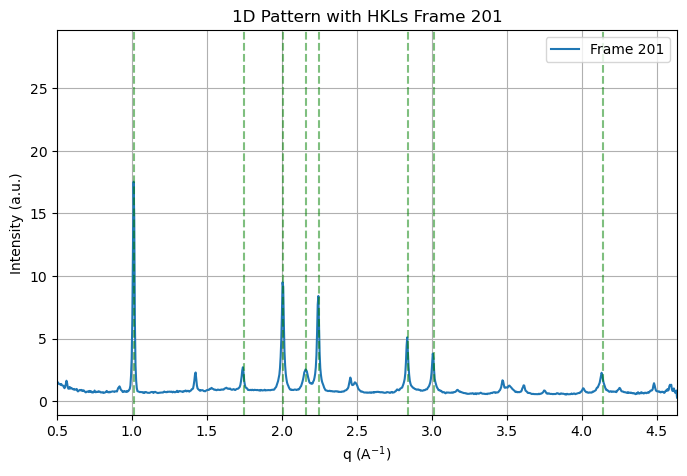

In [4]:
i = 200

# process_frame(i, q, time, intensity[i, :], matched_peaks, prev_fit_params, output_dir)
frame_idx = i + 1
I = intensity[i, :]
vline_subfolder = os.path.join(output_dir, f'VlinePlots')
os.makedirs(vline_subfolder, exist_ok=True)
plt.figure(figsize=(8,5))
plt.plot(q, I, label=f'Frame {frame_idx}')
# for (h, k, l, q_target) in matched_peaks:
#     plt.axvline(q_target, color='r', linestyle='--', alpha=0.5)
#     plt.text(q_target, np.max(I)*0.9, f'({h}{k}{l})', rotation=90, fontsize=8, ha='center')
for q_peak in q_peaks:
    plt.axvline(q_peak, color='g', linestyle='--', alpha=0.5)
plt.xlabel('q (A$^{-1}$)')
plt.xlim(.5, max(q))
plt.ylabel('Intensity (a.u.)')
plt.title(f'1D Pattern with HKLs Frame {frame_idx}')
plt.legend()
plt.grid()
plt.show()

In [15]:
frame_idx, frame_results = process_frame(i, q, time, intensity[i, :], matched_peaks, prev_fit_params, output_dir)

In [25]:
from pprint import pprint
pprint(frame_results['(001)'])
for key, value in frame_results.items():
    print(key, frame_results[key]['FWHM (A^-1)'])

{'Amplitude': np.float64(0.2947297372558444),
 'Background': np.float64(1.4596215652734148),
 'Center q (A^-1)': np.float64(1.0111309681346676),
 'FWHM (A^-1)': np.float64(0.014284672051847152),
 'Fraction': np.float64(0.553043746133084),
 'Frame': 200,
 'HKL': '(001)',
 'R_squared': np.float64(0.9959312246072136),
 'RedChi': np.float64(0.07577230592508097),
 'Scherrer Size (nm)': np.float64(24.55778731227546),
 'Sigma': np.float64(0.006617596865155152),
 'Time (s)': np.float64(280.0)}
(001) 0.014284672051847152
(111) 0.018145917280231436
(002) 0.017870367609447445
(012) 0.016506681213710097
(022) 0.01715508792920306
(003) 0.018866373666204597
(223) 0.028735715794206154


In [28]:
#xray energy
xray_energy = 10.0  # in keV
# Calculate the wavelength from the energy
wavelength = 12.398 / xray_energy  # in Angstroms

In [32]:
def delta_q_from_delta_2theta(delta2theta_deg, wavelength):
    """
    Convert an angular instrumental broadening Δ(2θ) to Δq,
    assuming small θ so cosθ≈1.

    Parameters
    ----------
    delta2theta_deg : float
        Instrumental broadening in degrees (Δ(2θ)).
    wavelength : float
        X-ray wavelength in Å.

    Returns
    -------
    delta_q : float
        Approximate q-space broadening in Å⁻¹.
    """
    # convert degrees -> radians
    d2t_rad = np.deg2rad(delta2theta_deg)
    print(f"Converting Δ(2θ) from {delta2theta_deg} degrees to radians: {d2t_rad:.4f} rad")
    return (2 * np.pi / wavelength) * d2t_rad
print(f"Calculated wavelength: {wavelength:.4f} A")
q_broadening = delta_q_from_delta_2theta(0.1, wavelength)
print(f"q broadening from 0.1 degree Δ(2θ): {q_broadening:.4f} A^-1")

Calculated wavelength: 1.2398 A
Converting Δ(2θ) from 0.1 degrees to radians: 0.0017 rad
q broadening from 0.1 degree Δ(2θ): 0.0088 A^-1


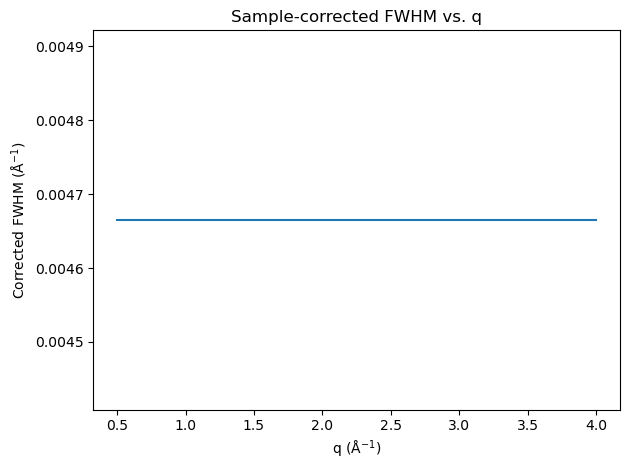

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- User parameters ---
wavelength = 1.2398  # X-ray wavelength in Å (e.g., Cu Kα)
delta2theta_deg = 0.1  # Instrumental broadening Δ(2θ) in degrees

# Convert Δ(2θ) to radians and then to Δq
delta2theta_rad = np.deg2rad(delta2theta_deg)
instrument_dq = (2 * np.pi / wavelength) * delta2theta_rad

# Generate q-array from 0.5 to 4 Å⁻¹
q = np.linspace(0.5, 4.0, 100)

# --- Measured FWHM in q-space (Å⁻¹) ---
# Replace this synthetic example with your actual measured values array
# measured_fwhm = np.loadtxt('measured_fwhm.txt')
measured_fwhm = 0.01*np.ones(len(q))  # example linear trend

# Compute corrected FWHM: deconvolve instrument broadening in quadrature
corrected_fwhm = np.sqrt(np.clip(measured_fwhm**2 - instrument_dq**2, 0, None))

# Plot
plt.figure()
plt.plot(q, corrected_fwhm)
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Corrected FWHM (Å$^{-1}$)')
plt.title('Sample-corrected FWHM vs. q')
plt.tight_layout()
plt.show()
